# 04 — The embedding is not a function of the adjacency spectrum

A natural worry about any spectral-flavored graph representation: maybe the
sorted output distribution is just the adjacency spectrum in disguise. This
notebook refutes that with **exact witnesses** and then asks the harder,
functional question — are the non-spectral differences *useful*?

$$
\operatorname{spec}(A_G) = \operatorname{spec}(A_H)
\quad\text{and}\quad G \not\cong H
\quad\Longrightarrow\quad
\Phi_{\mathrm{QuIC}}(G) \ne \Phi_{\mathrm{QuIC}}(H)\ ?
$$

The workflow, all regenerated from scratch in this notebook (nothing loaded
from disk):

```
enumerate every connected cubic graph at n = 14 and n = 16   (nauty-geng)
        |
group by EXACT integer cospectrality (trace tuples, no tolerance)
        |
verify non-isomorphism + identical integer characteristic polynomials
        |
audit classical invariants within each group (what ties, what varies)
        |
compute QuIC embeddings; measure separation against the isomorphism null
        |
rank the varying invariants from embedding differences
(with the spectrum as a chance-by-construction control)
```

A cospectrality note specific to regular graphs: color refinement (1-WL)
assigns every vertex of a regular graph the same color, so *any* two cubic
graphs of the same order are 1-WL-indistinguishable — including every pair
below. No comparison against higher WL levels is made or implied here.


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import quic
from quic import theory  # noqa: F401  (used by later notebooks)

# Consistent, colorblind-safe styling across the notebook series (Okabe-Ito).
OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
         "vermillion": "#D55E00", "purple": "#CC79A7", "sky": "#56B4E9",
         "black": "#000000"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10.5, "axes.titlesize": 11.5, "figure.constrained_layout.use": True,
})

report = quic.selfcheck()


selfcheck passed: 14 check groups, worst qiskit/numpy disagreement 2.78e-16


## 1. Exact cospectral censuses, no tolerance anywhere

Adjacency matrices are integer, so cospectrality is decidable *exactly*:
$\operatorname{tr}(A^k)$ for $k = 1..n$ counts closed walks (bounded by
$n\,3^n$, comfortably inside int64), and by Newton's identities the trace
tuple determines the characteristic polynomial. Two graphs are cospectral iff
their trace tuples are equal — integer comparison, no rounding, no hash.


In [2]:
from collections import Counter

from quic.datasets import cubic_census
from quic.graph_features import cospectral_groups

CENSUS, GROUPS, ADJ = {}, {}, {}
for n in (14, 16):
    graphs, g6 = cubic_census(n)
    ADJ[n] = [nx.to_numpy_array(g) for g in graphs]
    CENSUS[n] = graphs
    GROUPS[n] = cospectral_groups(ADJ[n])
    sizes = Counter(len(g) for g in GROUPS[n])
    print(f"n={n}: {len(graphs)} cubic graphs -> {len(GROUPS[n])} exact "
          f"cospectral groups, {sum(map(len, GROUPS[n]))} members, sizes {dict(sizes)}")

assert GROUPS[14] == [[79, 458], [201, 203], [234, 239]]
assert len(GROUPS[16]) == 41 and Counter(map(len, GROUPS[16]))== Counter({2: 40, 3: 1})
assert [582, 3061, 3800] in GROUPS[16]   # the one cospectral triple

n=14: 509 cubic graphs -> 3 exact cospectral groups, 6 members, sizes {2: 3}


n=16: 4060 cubic graphs -> 41 exact cospectral groups, 83 members, sizes {2: 40, 3: 1}


## 2. The featured witness

Graphs 201 and 203 of the $n = 14$ census (indices in deterministic
`nauty-geng` order). The checks below establish, exactly: they are not
isomorphic, and their characteristic polynomials are *identical as integer
polynomials* (computed by Faddeev–LeVerrier in exact arithmetic — the
floating-point eigenvalue agreement shown alongside is just corroboration).


non-isomorphic: True (VF2)
identical integer characteristic polynomial:
  (1, 0, -21, -2, 162, 24, -585, -84, 1038, 100, -834, -6, 223, -48, 0)
float eigenvalue agreement (corroboration): 2.2e-15


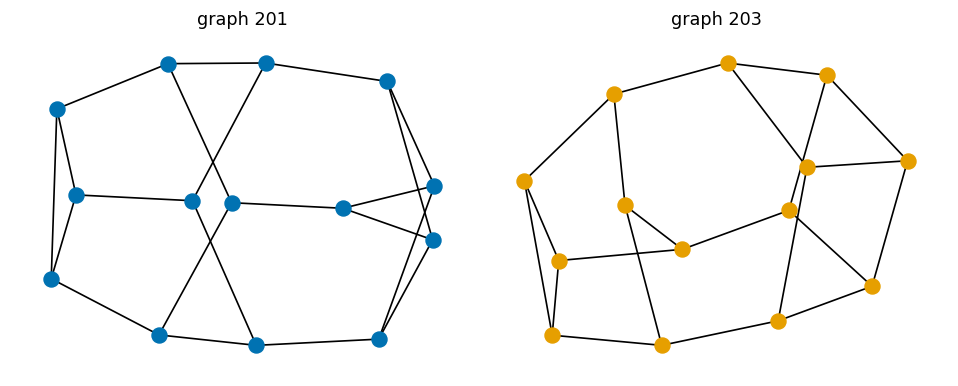

In [3]:
from quic.graph_features import characteristic_polynomial_int

gA, gB = CENSUS[14][201], CENSUS[14][203]
assert not nx.is_isomorphic(gA, gB)

charA = characteristic_polynomial_int(nx.to_numpy_array(gA))
charB = characteristic_polynomial_int(nx.to_numpy_array(gB))
assert charA == charB
float_gap = np.max(np.abs(np.sort(np.linalg.eigvalsh(nx.to_numpy_array(gA)))
                          - np.sort(np.linalg.eigvalsh(nx.to_numpy_array(gB)))))

print("non-isomorphic: True (VF2)")
print(f"identical integer characteristic polynomial:\n  {charA}")
print(f"float eigenvalue agreement (corroboration): {float_gap:.1e}")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4))
for ax, (G, name, color) in zip(axes, [(gA, "graph 201", OKABE["blue"]),
                                        (gB, "graph 203", OKABE["orange"])]):
    nx.draw(G, ax=ax, node_size=95, node_color=color, width=1.1,
            pos=nx.kamada_kawai_layout(G))
    ax.set_title(name)
plt.show()

## 3. What the spectrum pins, and what escapes it

On a cubic graph the spectrum fixes more than eigenvalues. The trace
identities force every cospectral pair to agree on $C_3$, $C_4$ and (through
regularity) $C_5$ and girth; and since
$\operatorname{tr}(A^6) = 12\,(C_6 + D_\diamond) + 87n + 6C_3 + 96C_4$
exactly on cubic graphs, the spectrum also pins the *sum* $C_6 + D_\diamond$
(within these censuses the split never trades off inside a group, so $C_6$
and $D_\diamond$ tie separately). The consequence for the theory of notebook
02 is sharp: the pair census $(C_3, C_4, D_\diamond)$ — everything the
second-order purity closure sees, everything the certified two-defect head
encodes at first order — is **identical within every cospectral group**.
Whatever separates the embeddings is higher-order structure.

What actually varies within groups is *global*: Wiener index (total distance),
automorphism count, and (at $n=16$) radius. For the featured pair:


In [4]:
import pandas as pd

from quic.graph_features import graph_invariants, validate_cycle_identities

for G in (gA, gB):
    validate_cycle_identities(G)   # trace identities incl. cubic C6+diamond

audit = pd.DataFrame({"graph 201": graph_invariants(gA),
                      "graph 203": graph_invariants(gB)})
audit["ties"] = np.where(audit["graph 201"] == audit["graph 203"], "=", "DIFFERS")
print(audit.to_string())

                   graph 201  graph 203     ties
C3                         1          1        =
C4                         3          3        =
C5                         3          3        =
C6                        10         10        =
C7                         3          3        =
girth                      3          3        =
diameter                   4          4        =
radius                     3          3        =
wiener                   209        208  DIFFERS
node_connectivity          3          3        =
edge_connectivity          3          3        =
matching_number            7          7        =
clique_number              3          3        =
aut_order                 12          6  DIFFERS

## 4. The embeddings separate — measured against the honest null

The QuIC embeddings of 201 and 203, computed exactly. The yardstick (notebook
01) is the **isomorphism null**: the embedding distance between graph 201 and
a randomly relabeled copy of itself, which bounds numerical noise. The
witness separation sits about **ten orders of magnitude above the null**.

Where does the separation live? The certified $\le 2$-defect head (first 106
coordinates) carries most of the *absolute* $\ell_1$ separation — its
coordinates are the largest, and although the pair census ties (so the head
agrees to first order in $\beta$), higher-order corrections shift the largest
probabilities by parts in $10^{2\text{–}3}$. Beyond the head the absolute
differences are smaller but *relatively* larger. Both regions carry signal;
neither is an artifact.


L1 separation:      1.692e-05   (head 1.45e-05, tail 2.42e-06)
isomorphism null:   7.031e-16


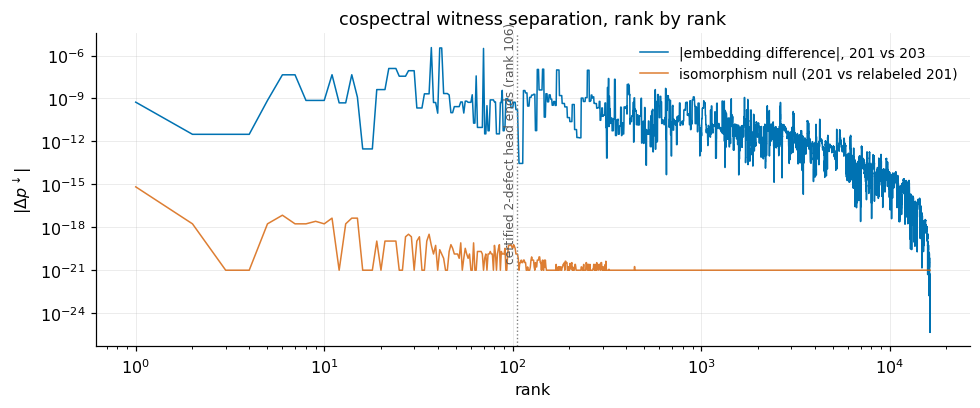

In [5]:
from quic import circuit_probabilities
from quic.readouts import readout_R0

def embedding(A):
    return readout_R0(circuit_probabilities(np.asarray(A, dtype=float)))

eA, eB = embedding(nx.to_numpy_array(gA)), embedding(nx.to_numpy_array(gB))
delta = np.abs(eA - eB)

rng = np.random.default_rng(1)
perm = rng.permutation(14)
A201 = nx.to_numpy_array(gA)
null_vec = np.abs(eA - embedding(A201[np.ix_(np.argsort(perm), np.argsort(perm))]))

head = 1 + 14 + (14 * 13) // 2   # certified two-defect head, notebook 02
print(f"L1 separation:      {delta.sum():.3e}   (head {delta[:head].sum():.2e}, "
      f"tail {delta[head:].sum():.2e})")
print(f"isomorphism null:   {null_vec.sum():.3e}")

fig, ax = plt.subplots(figsize=(8.8, 3.6))
ranks = np.arange(1, len(delta) + 1)
ax.loglog(ranks, delta, linewidth=1.0, color=OKABE["blue"],
          label="|embedding difference|, 201 vs 203")
ax.loglog(ranks, np.maximum(null_vec, 1e-21), linewidth=1.0,
          color=OKABE["vermillion"], alpha=0.8,
          label="isomorphism null (201 vs relabeled 201)")
ax.axvline(head, color="0.5", linewidth=0.9, linestyle=":")
ax.annotate("certified 2-defect head ends (rank 106)", (head, 3e-21),
            rotation=90, fontsize=8, color="0.35", ha="right", va="bottom")
ax.set_xlabel("rank")
ax.set_ylabel("$|\\Delta p^{\\downarrow}|$")
ax.set_title("cospectral witness separation, rank by rank")
ax.legend(frameon=False, fontsize=9)
plt.show()

## 5. Not an artifact of one angle

The separation should not depend on a lucky entangler angle. Sweeping
$\gamma$ across $[0.4, 3.0]$ (all other angles canonical) for all three
$n = 14$ witness pairs: separation persists at every tested angle, orders of
magnitude above the null everywhere. The canonical $\gamma = 2.0$ is marked.


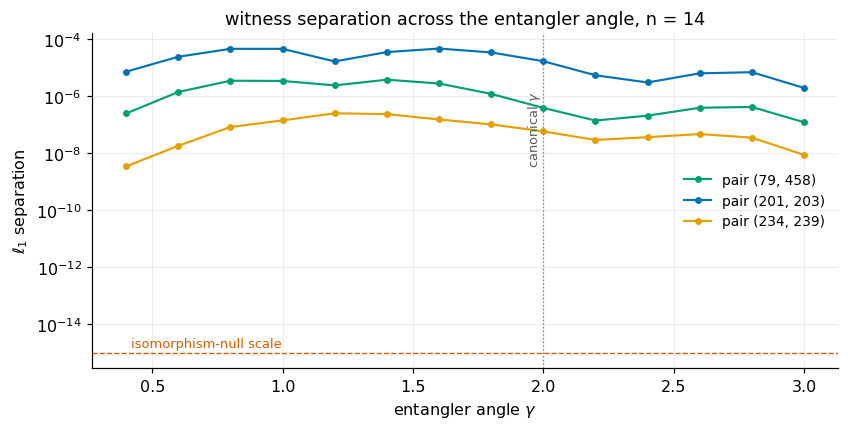

In [6]:
gamma_grid = np.linspace(0.4, 3.0, 14)
pair_colors = {(79, 458): OKABE["green"], (201, 203): OKABE["blue"],
               (234, 239): OKABE["orange"]}

fig, ax = plt.subplots(figsize=(7.6, 3.8))
for (i, j), color in pair_colors.items():
    seps = []
    for gamma in gamma_grid:
        ei = readout_R0(circuit_probabilities(ADJ[14][i], gamma=gamma))
        ej = readout_R0(circuit_probabilities(ADJ[14][j], gamma=gamma))
        seps.append(np.abs(ei - ej).sum())
    ax.semilogy(gamma_grid, seps, marker="o", markersize=3.5, linewidth=1.4,
                color=color, label=f"pair ({i}, {j})")
ax.axvline(quic.CANONICAL_GAMMA, color="0.5", linewidth=0.9, linestyle=":")
ax.annotate("canonical $\\gamma$", (quic.CANONICAL_GAMMA, ax.get_ylim()[0] * 1.5),
            fontsize=8.5, color="0.35", ha="right", rotation=90, va="bottom")
ax.axhline(1e-15, color=OKABE["vermillion"], linewidth=0.9, linestyle="--")
ax.annotate("isomorphism-null scale", (0.42, 1.6e-15), fontsize=8.5,
            color=OKABE["vermillion"])
ax.set_xlabel("entangler angle $\\gamma$")
ax.set_ylabel("$\\ell_1$ separation")
ax.set_title("witness separation across the entangler angle, n = 14")
ax.legend(frameon=False, fontsize=9)
plt.show()

## 6. Every cospectral group, both censuses

Scaling the same measurement to all 44 exact groups (3 at $n = 14$, 41 at
$n = 16$; 89 graphs, embeddings up to dimension $2^{16}$, all computed here).
Every within-group pair of non-isomorphic graphs is separated; the smallest
separation across both censuses is still about seven orders of magnitude
above the null.


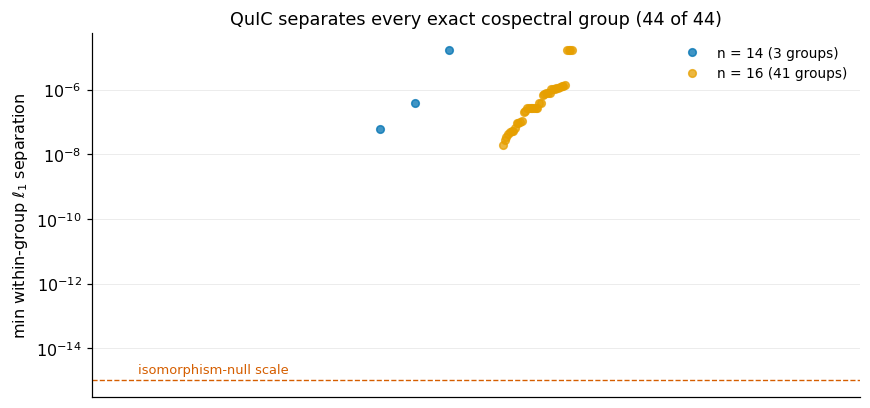

smallest separation, n=14: 5.87e-08
smallest separation, n=16: 1.92e-08


In [7]:
from itertools import combinations

group_min_sep = {14: [], 16: []}
for n in (14, 16):
    for grp in GROUPS[n]:
        embs = {i: embedding(ADJ[n][i]) for i in grp}
        min_sep = min(np.abs(embs[i] - embs[j]).sum()
                      for i, j in combinations(grp, 2))
        group_min_sep[n].append(min_sep)
    assert min(group_min_sep[n]) > 1e-9

fig, ax = plt.subplots(figsize=(7.8, 3.6))
for n, color, offset in [(14, OKABE["blue"], -0.08), (16, OKABE["orange"], 0.08)]:
    vals = np.array(group_min_sep[n])
    x = np.full(len(vals), 0.5 + offset) + np.linspace(-0.045, 0.045, len(vals))
    ax.semilogy(x, np.sort(vals), "o", markersize=5, alpha=0.75, color=color,
                label=f"n = {n} ({len(vals)} groups)")
ax.axhline(1e-15, color=OKABE["vermillion"], linewidth=0.9, linestyle="--")
ax.annotate("isomorphism-null scale", (0.06, 1.7e-15), fontsize=8.5,
            color=OKABE["vermillion"])
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_ylabel("min within-group $\\ell_1$ separation")
ax.set_title("QuIC separates every exact cospectral group (44 of 44)")
ax.legend(frameon=False, fontsize=9)
import os
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/cospectral_separation.png")
plt.show()

print(f"smallest separation, n=14: {min(group_min_sep[14]):.2e}")
print(f"smallest separation, n=16: {min(group_min_sep[16]):.2e}")

## 7. From existence to function: ranking inside cospectral classes

Separation alone says the embedding *contains* non-spectral information. The
functional question: do the embedding differences **predict** the invariants
that actually vary within exact cospectral classes — Wiener index (25 varying
groups at $n = 16$) and automorphism count (14 groups)?

The protocol (fixed before results): for each within-group pair, predict
$\operatorname{sign}(y_i - y_j)$ from the difference of truncated embeddings
$\Phi_k(G_i) - \Phi_k(G_j)$ at $k = 100$. Leave-one-group-out so no group
ever straddles train and test; both orientations of every training pair with
an intercept-free $L_2$ logistic ranker, making the decision function exactly
antisymmetric; one scalar RMS feature rescale fit on training folds;
regularization chosen by group-wise inner CV. Significance is an exact
one-sided binomial test against chance, with the threshold printed *before*
the score. **The adjacency spectrum runs as a control**: within exact
cospectral groups its feature differences are zero to eigensolver noise, so
it must score at chance — that is what makes the task meaningful.


In [8]:
import warnings

from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

warnings.filterwarnings("ignore")

members16 = sorted({i for grp in GROUPS[16] for i in grp})
EMB16 = {i: embedding(ADJ[16][i]) for i in members16}
SPEC16 = {i: np.sort(np.linalg.eigvalsh(ADJ[16][i])) for i in members16}

TARGETS = {}
for i in members16:
    G = CENSUS[16][i]
    spl = dict(nx.all_pairs_shortest_path_length(G))
    wiener = sum(d for u in spl for d in spl[u].values()) // 2
    aut = sum(1 for _ in nx.isomorphism.GraphMatcher(G, G).isomorphisms_iter())
    TARGETS[i] = {"wiener": float(wiener), "log2_aut": float(np.log2(aut))}


def rank_within_groups(target, vectors, k):
    pairs = [(gn, i, j, float(np.sign(TARGETS[i][target] - TARGETS[j][target])))
             for gn, grp in enumerate(GROUPS[16])
             for i, j in combinations(grp, 2)
             if TARGETS[i][target] != TARGETS[j][target]]
    X = np.vstack([vectors[i][:k] - vectors[j][:k] for _, i, j, _ in pairs])
    y = np.array([p[3] for p in pairs])
    gid = np.array([p[0] for p in pairs])
    correct = 0
    for hold in sorted(set(gid.tolist())):
        train = gid != hold
        scale = np.sqrt((X[train] ** 2).mean())
        Xb = np.vstack([X[train], -X[train]]) / scale
        yb = np.concatenate([y[train], -y[train]])
        gb = np.concatenate([gid[train], gid[train]])
        nfold = min(5, len(set(gid[train].tolist())))
        best_score, best_C = -np.inf, 1.0
        for C in np.logspace(-3, 3, 7):
            accs = [LogisticRegression(C=C, fit_intercept=False, max_iter=5000,
                                       random_state=0)
                    .fit(Xb[tr], yb[tr]).score(Xb[va], yb[va])
                    for tr, va in GroupKFold(n_splits=nfold).split(Xb, yb, gb)]
            if np.mean(accs) > best_score:
                best_score, best_C = np.mean(accs), C
        model = LogisticRegression(C=best_C, fit_intercept=False, max_iter=5000,
                                   random_state=0).fit(Xb, yb)
        for idx in np.nonzero(~train)[0]:
            decision = float(model.decision_function((X[idx] / scale).reshape(1, -1))[0])
            mirrored = float(model.decision_function((-X[idx] / scale).reshape(1, -1))[0])
            assert abs(decision + mirrored) < 1e-9    # antisymmetry: no intercept leak
            correct += (np.sign(decision) == y[idx]) and decision != 0.0
    n_pairs = len(pairs)
    threshold = int(stats.binom.isf(0.05, n_pairs, 0.5)) + 1
    p_value = stats.binomtest(correct, n_pairs, 0.5, alternative="greater").pvalue
    return correct, n_pairs, threshold, p_value


print(f"{'target':>9} {'features':>10} {'score':>7} {'needs':>6} {'p':>8}")
for target in ("wiener", "log2_aut"):
    c, m, t, p = rank_within_groups(target, EMB16, 100)
    print(f"{target:>9} {'QuIC k=100':>10} {c:>4}/{m:<3} {'>='+str(t):>5} {p:>8.4f}")
    c2, m2, t2, p2 = rank_within_groups(target, SPEC16, 16)
    print(f"{target:>9} {'spectrum':>10} {c2:>4}/{m2:<3} {'>='+str(t2):>5} {p2:>8.4f}   (control)")

spec_noise = max(np.abs(SPEC16[i] - SPEC16[j]).max()
                 for grp in GROUPS[16] for i, j in combinations(grp, 2))
print(f"\nlargest within-group spectral feature difference: {spec_noise:.1e} "
      f"(eigensolver noise -> control is chance by construction)")

   target   features   score  needs        p


   wiener QuIC k=100   18/26   >=18   0.0378


   wiener   spectrum    6/26   >=18   0.9988   (control)


 log2_aut QuIC k=100   14/14   >=11   0.0001


 log2_aut   spectrum   10/14   >=11   0.0898   (control)

largest within-group spectral feature difference: 6.0e-15 (eigensolver noise -> control is chance by construction)


## 8. What this establishes

**Representational.** On the complete cubic censuses at $n = 14$ and
$n = 16$, every exactly-cospectral group — certified over the integers — is
separated by the QuIC embedding, at every tested entangler angle, with
separations $10^{7}$–$10^{10}$ times the isomorphism null. The embedding is
not a function of the adjacency spectrum.

**Functional, honestly powered.** Within exact cospectral classes at
$n = 16$, truncated embedding differences rank the automorphism count
correctly on all 14 varying groups ($p = 10^{-4}$) and the Wiener index on
18 of 26 pairs ($p = 0.038$ — exactly at the pre-stated threshold, thin but
real), while the spectrum control sits at chance. These are statements about
these censuses at these orders; no universality is claimed, and 26 pairs is
a small sample by construction — exhaustive enumeration, not sampling, sets
the population size.

**Connection to the theory.** Everything the second-order closure of
notebook 02 sees — $C_3$, $C_4$, diamonds, the entire pair census — ties
within every one of these groups. The separation demonstrated here is
therefore evidence of accessible structure *beyond* the certified
second-order layer, which is precisely the regime the three-root theory
points at. What varies within groups is global (distance totals, symmetry),
and that is what the embedding differences turn out to rank.
